# Customer Segmentation → Classification Model for Deployment

**Objective:** Convert the K-Means clustering output into a supervised classification model that can predict customer segments for new, unseen customers in production.

**Why this conversion?**
- **Stable predictions:** K-Means centroids drift on re-run; a classifier gives consistent segment labels
- **Confidence scores:** `predict_proba()` tells us *how strongly* a customer belongs to a segment
- **Feature importance:** We learn *which features drive* segment membership — actionable for business
- **Deployment-ready:** Single `model.predict()` call, no dependency on full-dataset re-clustering

**Input:** `customer_segmentation_clustered.csv` (2236 rows × 12 features + Cluster_Label from K-Means)  
**Output:** Trained classifier + scaler artifacts (.pkl) for production deployment

---

## Step 1: Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import joblib

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# Load the clustered dataset (output of the K-Means pipeline)
df = pd.read_csv('customer_segmentation_clustered.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset Shape: (2236, 14)

Columns: ['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Response', 'Age', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 'Total_Campaigns_Accepted', 'Cluster', 'Cluster_Label']


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Response,Age,Total_Spend,Total_Purchases,Total_Dependents,Total_Campaigns_Accepted,Cluster,Cluster_Label
0,1,1,58138.0,58,3,7,1,69,1617,22,0,0,3,Premium Loyal
1,1,1,46344.0,38,2,5,0,72,27,4,2,0,1,Budget-Conscious
2,1,0,71613.0,26,1,4,0,61,776,20,0,0,2,High-Value
3,1,0,26646.0,26,2,6,0,42,53,6,1,0,1,Budget-Conscious
4,2,0,58293.0,94,5,5,0,45,422,14,1,0,0,Deal-Seeking Parents


## Step 2: Prepare Features & Target

We use the same 12 features from the clustering pipeline. The target is `Cluster_Label` — the business-meaningful segment names assigned by the auto-labeling logic.

In [3]:
# Define features (same 12 used in K-Means) and target
feature_cols = ['Income', 'Recency', 'Age', 'Total_Spend', 'Total_Purchases',
                'Total_Dependents', 'Total_Campaigns_Accepted', 'NumDealsPurchases',
                'NumWebVisitsMonth', 'Response', 'Education', 'Marital_Status']

X = df[feature_cols].copy()
y = df['Cluster_Label'].copy()

print(f'Features shape: {X.shape}')
print(f'Target classes:\n{y.value_counts()}')
print(f'\nClass proportions (%):\n{(y.value_counts(normalize=True)*100).round(1)}')

Features shape: (2236, 12)
Target classes:
Cluster_Label
Budget-Conscious        973
High-Value              627
Deal-Seeking Parents    409
Premium Loyal           227
Name: count, dtype: int64

Class proportions (%):
Cluster_Label
Budget-Conscious        43.5
High-Value              28.0
Deal-Seeking Parents    18.3
Premium Loyal           10.2
Name: proportion, dtype: float64


In [4]:
# Encode target labels to integers for sklearn
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Store the mapping for reference
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Encoding Mapping:')
for name, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f'  {code} → {name}')

Label Encoding Mapping:
  0 → Budget-Conscious
  1 → Deal-Seeking Parents
  2 → High-Value
  3 → Premium Loyal


## Step 3: Train-Test Split

We use stratified splitting to preserve class proportions in both sets — critical because Premium Loyal is only 10% of the data.

In [5]:
# 80/20 stratified split — preserves class ratios in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Verify stratification preserved class proportions
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
print(f'\nClass distribution check (proportions):')
print(f'  {"Class":<10} {"Train":>8} {"Test":>8}')
for cls in sorted(label_mapping.values()):
    name = le.inverse_transform([cls])[0]
    print(f'  {name:<25} {train_dist[cls]:.3f}    {test_dist[cls]:.3f}')

Training set: 1788 samples
Test set:     448 samples

Class distribution check (proportions):
  Class         Train     Test
  Budget-Conscious          0.435    0.435
  Deal-Seeking Parents      0.183    0.183
  High-Value                0.280    0.281
  Premium Loyal             0.102    0.100


## Step 4: Feature Scaling

Same StandardScaler approach as the clustering pipeline — fit on training data only, transform both sets to prevent data leakage.

In [6]:
# Fit scaler on training data ONLY (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling
scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
print('Scaled training data stats (should be ~mean=0, std=1):')
print(scaled_df.describe().loc[['mean', 'std']].round(3))

Scaled training data stats (should be ~mean=0, std=1):
      Income  Recency  Age  Total_Spend  Total_Purchases  Total_Dependents  \
mean     0.0     -0.0  0.0          0.0             -0.0               0.0   
std      1.0      1.0  1.0          1.0              1.0               1.0   

      Total_Campaigns_Accepted  NumDealsPurchases  NumWebVisitsMonth  \
mean                       0.0                0.0               -0.0   
std                        1.0                1.0                1.0   

      Response  Education  Marital_Status  
mean      -0.0       -0.0             0.0  
std        1.0        1.0             1.0  


## Step 5: Model Comparison (4 Classifiers)

We compare 4 algorithms using 5-fold stratified cross-validation on the training set. All models use `class_weight='balanced'` to handle the imbalanced classes (Premium Loyal = 10% vs Budget-Conscious = 44%).

| Model | Why We Try It |
|---|---|
| Logistic Regression | Simple baseline, gives probabilities, highly interpretable |
| Random Forest | Handles non-linear boundaries, built-in feature importance |
| Gradient Boosting | Often best accuracy, sequential error correction |
| SVM (RBF kernel) | Good with scaled data, captures complex boundaries |

> **Design Note:** We don't know which model will win until the comparison runs. The entire pipeline from Step 6 onward is written to be **model-agnostic** — it automatically adapts to whichever model scores highest here. This means if you re-run this notebook on a different dataset where Random Forest wins instead, Steps 6–11 will work without any code changes.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL-AGNOSTIC DESIGN: We define all 4 candidate models upfront.
# The winner is selected programmatically in Step 6 — no hardcoded assumptions.
# This makes the notebook reusable: swap datasets, and the pipeline still works.
# ─────────────────────────────────────────────────────────────────────────────

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42  # GB doesn't support class_weight; we handle it in tuning
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    )
}

# 5-fold stratified cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25} {"Accuracy (mean±std)":>20} {"F1-Weighted (mean±std)":>25}')
print('=' * 75)

cv_results = {}
for name, model in models.items():
    # Accuracy
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    # Weighted F1 — better metric for imbalanced classes
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
    
    cv_results[name] = {
        'acc_mean': acc_scores.mean(), 'acc_std': acc_scores.std(),
        'f1_mean': f1_scores.mean(), 'f1_std': f1_scores.std()
    }
    print(f'{name:<25} {acc_scores.mean():.4f} ± {acc_scores.std():.4f}      '
          f'{f1_scores.mean():.4f} ± {f1_scores.std():.4f}')

Model                      Accuracy (mean±std)    F1-Weighted (mean±std)
Logistic Regression       0.9771 ± 0.0059      0.9773 ± 0.0058
Random Forest             0.9575 ± 0.0074      0.9572 ± 0.0074
Gradient Boosting         0.9541 ± 0.0063      0.9541 ± 0.0062
SVM (RBF)                 0.9625 ± 0.0076      0.9631 ± 0.0073


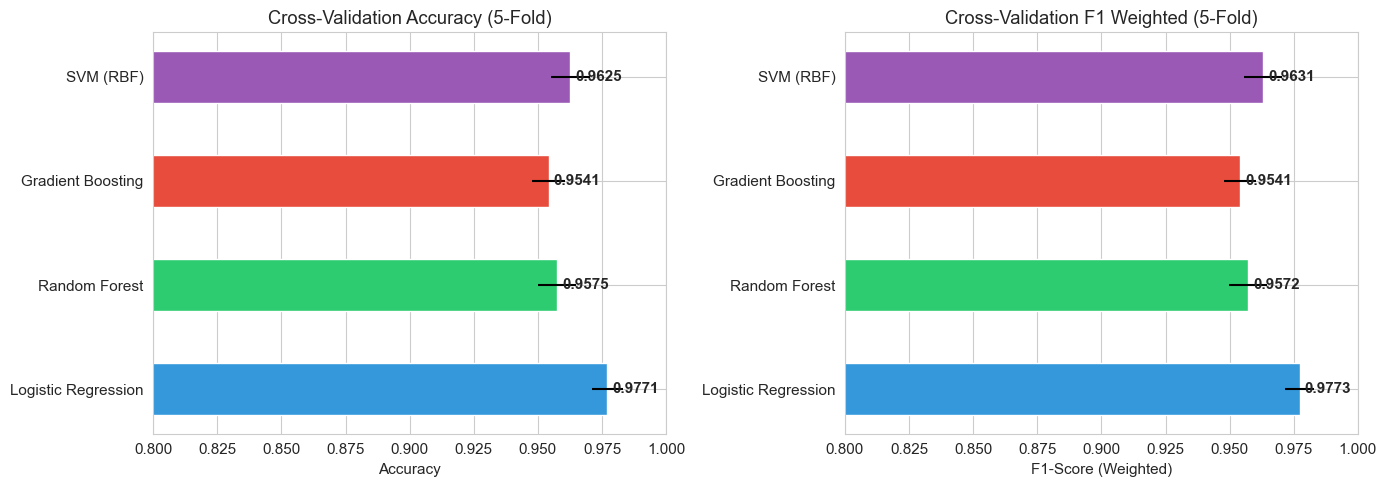


Model comparison chart saved.


In [8]:
# Visualize cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(cv_results.keys())
acc_means = [cv_results[m]['acc_mean'] for m in model_names]
f1_means = [cv_results[m]['f1_mean'] for m in model_names]
acc_stds = [cv_results[m]['acc_std'] for m in model_names]
f1_stds = [cv_results[m]['f1_std'] for m in model_names]

# Accuracy comparison
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
axes[0].barh(model_names, acc_means, xerr=acc_stds, color=colors, edgecolor='white', height=0.5)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Cross-Validation Accuracy (5-Fold)')
axes[0].set_xlim(0.8, 1.0)
for i, v in enumerate(acc_means):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

# F1 comparison
axes[1].barh(model_names, f1_means, xerr=f1_stds, color=colors, edgecolor='white', height=0.5)
axes[1].set_xlabel('F1-Score (Weighted)')
axes[1].set_title('Cross-Validation F1 Weighted (5-Fold)')
axes[1].set_xlim(0.8, 1.0)
for i, v in enumerate(f1_means):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nModel comparison chart saved.')

## Step 6: Hyperparameter Tuning (Best Model)

We tune the top-performing model from Step 5 using GridSearchCV with stratified 5-fold CV.

> **Why are there hyperparameter grids for all 4 models below?** Because the winner is selected **dynamically** by `best_model_name = max(cv_results, ...)`. Only the grid matching the winner is actually used by GridSearchCV — the others sit idle. This way, if a different model wins on a different dataset, the tuning step works automatically without code changes. This is a standard **model-agnostic pipeline** pattern used in production ML.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# DYNAMIC MODEL SELECTION: This line picks whichever model scored highest in
# Step 5. On our data, Logistic Regression wins. On a different dataset,
# Random Forest or SVM might win — and everything below still works.
# ─────────────────────────────────────────────────────────────────────────────
best_model_name = max(cv_results, key=lambda m: cv_results[m]['f1_mean'])
print(f'Best model from CV: {best_model_name} (F1={cv_results[best_model_name]["f1_mean"]:.4f})')

# Hyperparameter grids for ALL models — only the winner's grid is used.
# Keeping all grids here makes the notebook a reusable template:
# re-run on new data → different winner → correct grid is auto-selected.
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'min_samples_split': [2, 5, 10]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    }
}

# GridSearchCV only uses param_grids[best_model_name] — the rest are ignored
grid_search = GridSearchCV(
    models[best_model_name],
    param_grids[best_model_name],
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV F1 (weighted): {grid_search.best_score_:.4f}')

# Store the tuned model — from here on, all code uses 'best_model' generically
best_model = grid_search.best_estimator_

Best model from CV: Logistic Regression (F1=0.9773)

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 (weighted): 0.9888


## Step 7: Final Evaluation on Test Set

This is the moment of truth — evaluating the tuned model on data it has **never seen**.

In [10]:
# Predict on the held-out test set
y_pred = best_model.predict(X_test_scaled)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# Overall metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Test Accuracy:    {test_accuracy:.4f}')
print(f'Test F1 Weighted: {test_f1:.4f}')

# Per-class classification report
print(f'\n{"="*70}')
print('CLASSIFICATION REPORT')
print(f'{"="*70}')
print(classification_report(y_test_labels, y_pred_labels, 
                            target_names=le.classes_, digits=4))

Test Accuracy:    0.9955
Test F1 Weighted: 0.9956

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

    Budget-Conscious     1.0000    0.9897    0.9948       195
Deal-Seeking Parents     0.9762    1.0000    0.9880        82
          High-Value     1.0000    1.0000    1.0000       126
       Premium Loyal     1.0000    1.0000    1.0000        45

            accuracy                         0.9955       448
           macro avg     0.9940    0.9974    0.9957       448
        weighted avg     0.9956    0.9955    0.9956       448



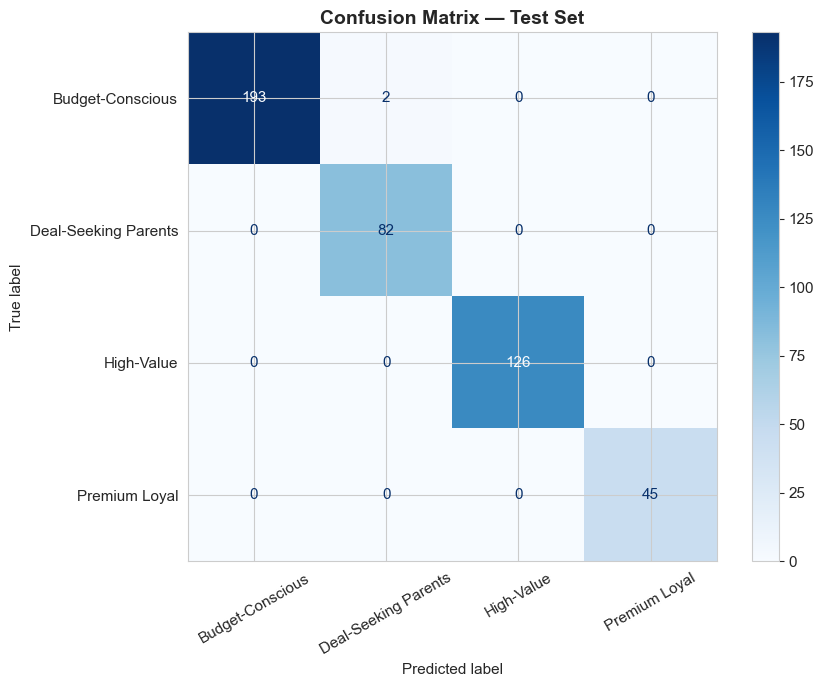


Total misclassified: 2 / 448 (0.4%)


In [11]:
# Confusion Matrix — shows exactly where misclassifications happen
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=30)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Misclassification analysis
total_misclassified = (y_test != y_pred).sum()
print(f'\nTotal misclassified: {total_misclassified} / {len(y_test)} ({total_misclassified/len(y_test)*100:.1f}%)')

## Step 8: Feature Importance Analysis

Understanding *which features drive segment predictions* — this is one of the key advantages of classification over clustering.

> **Adaptive logic below:** Tree-based models (Random Forest, Gradient Boosting) have built-in Gini importance via `.feature_importances_`. Linear models (Logistic Regression, SVM) don't, so the code falls back to **permutation importance** — a model-agnostic method. The `hasattr()` check makes this step work correctly regardless of which model won in Step 5.

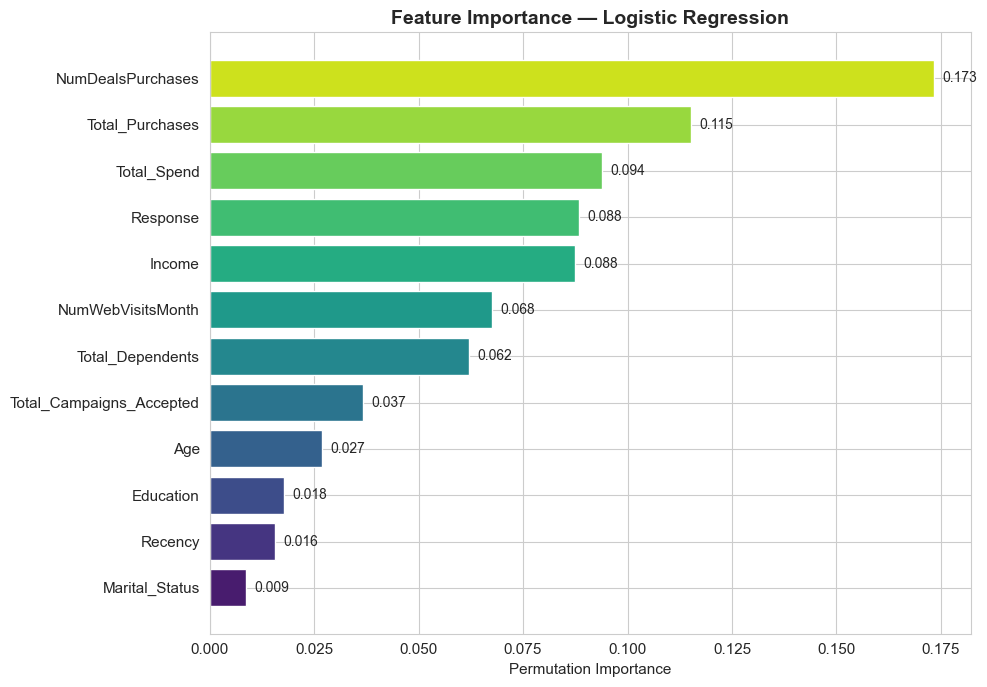


Top 5 Features (Permutation Importance):
  NumDealsPurchases              0.1734
  Total_Purchases                0.1152
  Total_Spend                    0.0940
  Response                       0.0884
  Income                         0.0875


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# ADAPTIVE FEATURE IMPORTANCE: Different model families expose importance
# differently. This code auto-detects the model type and uses the right method.
#   - If RF or GB won → uses built-in .feature_importances_ (Gini importance)
#   - If LR or SVM won → uses permutation importance (model-agnostic fallback)
# Result: this cell works for ANY model without modification.
# ─────────────────────────────────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models (RF, GB) have built-in Gini importance
    importances = best_model.feature_importances_
    importance_type = 'Gini Importance'
else:
    # Linear models (LR, SVM) — use permutation importance instead
    # Shuffles each feature and measures accuracy drop
    perm_result = permutation_importance(best_model, X_test_scaled, y_test, 
                                         n_repeats=10, random_state=42)
    importances = perm_result.importances_mean
    importance_type = 'Permutation Importance'

# Sort features by importance
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], 
               color=sns.color_palette('viridis', len(feature_cols)), edgecolor='white')
ax.set_xlabel(importance_type)
ax.set_title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 5 Features ({importance_type}):')
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f'  {row["Feature"]:<30} {row["Importance"]:.4f}')

## Step 9: Prediction Confidence Analysis

One of the biggest advantages over K-Means — we can now see *how confident* the model is about each prediction.

> **Why the `hasattr` check?** Most classifiers support `predict_proba()`, but some (like a basic SVM without `probability=True`) don't. The check ensures this step degrades gracefully rather than crashing, regardless of which model won in Step 5.

Prediction Confidence Statistics:
  Mean:   0.986
  Median: 1.000
  Min:    0.504
  Max:    1.000
  Std:    0.065


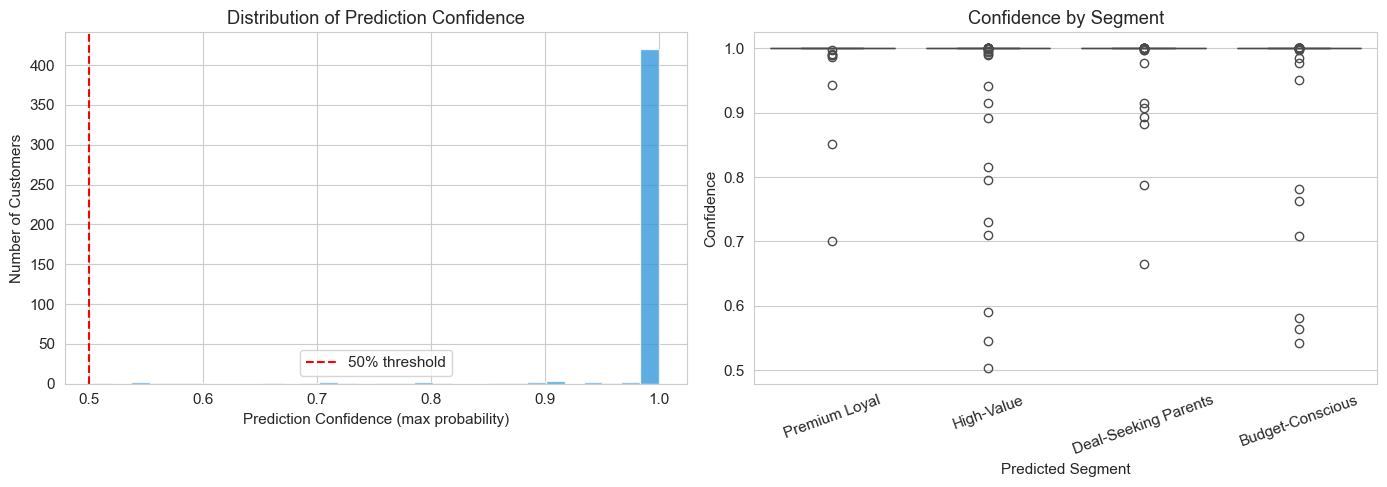


Low-confidence predictions (<50%): 0 / 448 (0.0%)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# GRACEFUL DEGRADATION: Not all classifiers support predict_proba().
# The hasattr check ensures this step works for any model:
#   - LR, RF, GB, SVM(probability=True) → full confidence analysis
#   - SVM(probability=False) or other models → skip with informative message
# ─────────────────────────────────────────────────────────────────────────────
if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test_scaled)
    
    # Confidence = max probability across classes for each sample
    confidence = y_proba.max(axis=1)
    
    print(f'Prediction Confidence Statistics:')
    print(f'  Mean:   {confidence.mean():.3f}')
    print(f'  Median: {np.median(confidence):.3f}')
    print(f'  Min:    {confidence.min():.3f}')
    print(f'  Max:    {confidence.max():.3f}')
    print(f'  Std:    {confidence.std():.3f}')
    
    # Confidence distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of confidence scores
    axes[0].hist(confidence, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0].axvline(0.5, color='red', linestyle='--', label='50% threshold')
    axes[0].set_xlabel('Prediction Confidence (max probability)')
    axes[0].set_ylabel('Number of Customers')
    axes[0].set_title('Distribution of Prediction Confidence')
    axes[0].legend()
    
    # Confidence by predicted segment
    conf_df = pd.DataFrame({
        'Predicted_Segment': le.inverse_transform(y_pred),
        'Confidence': confidence,
        'Correct': y_test == y_pred
    })
    
    segment_order = ['Premium Loyal', 'High-Value', 'Deal-Seeking Parents', 'Budget-Conscious']
    conf_df['Predicted_Segment'] = pd.Categorical(conf_df['Predicted_Segment'], 
                                                   categories=segment_order, ordered=True)
    
    sns.boxplot(data=conf_df, x='Predicted_Segment', y='Confidence', ax=axes[1],
                palette=['#e74c3c', '#2ecc71', '#f39c12', '#3498db'])
    axes[1].set_xlabel('Predicted Segment')
    axes[1].set_ylabel('Confidence')
    axes[1].set_title('Confidence by Segment')
    axes[1].tick_params(axis='x', rotation=20)
    
    plt.tight_layout()
    plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Low-confidence customers (potential segment boundaries)
    low_conf = conf_df[conf_df['Confidence'] < 0.5]
    print(f'\nLow-confidence predictions (<50%): {len(low_conf)} / {len(conf_df)} '
          f'({len(low_conf)/len(conf_df)*100:.1f}%)')
else:
    print('Model does not support predict_proba — skipping confidence analysis.')

## Step 10: New Customer Prediction Demo

This demonstrates how the deployed model would classify a brand-new customer.

In [14]:
# Simulate a new customer entering the system
new_customer = pd.DataFrame({
    'Income': [65000],
    'Recency': [15],
    'Age': [45],
    'Total_Spend': [1200],
    'Total_Purchases': [18],
    'Total_Dependents': [0],
    'Total_Campaigns_Accepted': [2],
    'NumDealsPurchases': [1],
    'NumWebVisitsMonth': [3],
    'Response': [1],
    'Education': [2],       # Postgraduate
    'Marital_Status': [0]   # Partnered
})

# Scale using the SAME scaler fitted on training data
new_scaled = scaler.transform(new_customer)

# Predict segment
predicted_label = le.inverse_transform(best_model.predict(new_scaled))[0]

# Get confidence scores for all segments
if hasattr(best_model, 'predict_proba'):
    proba = best_model.predict_proba(new_scaled)[0]
    print('NEW CUSTOMER PREDICTION')
    print('=' * 50)
    print(f'\nPredicted Segment: {predicted_label}')
    print(f'\nConfidence per segment:')
    for cls, prob in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = '█' * int(prob * 40)
        print(f'  {cls:<25} {prob:.2%}  {bar}')
else:
    print(f'Predicted Segment: {predicted_label}')

NEW CUSTOMER PREDICTION

Predicted Segment: Premium Loyal

Confidence per segment:
  Premium Loyal             100.00%  ████████████████████████████████████████
  High-Value                0.00%  
  Deal-Seeking Parents      0.00%  
  Budget-Conscious          0.00%  


## Step 11: Save Deployment Artifacts

Three files for production — the scaler, classifier, and label encoder.

In [15]:
# Save all 3 deployment artifacts
joblib.dump(scaler, 'classification_scaler.pkl')
joblib.dump(best_model, 'classification_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print('Deployment artifacts saved:')
print(f'  1. classification_scaler.pkl  — StandardScaler (fitted on training data)')
print(f'  2. classification_model.pkl   — {best_model_name} (tuned)')
print(f'  3. label_encoder.pkl          — LabelEncoder (maps integers ↔ segment names)')
print(f'\n--- Production Usage ---')
print(f'scaler = joblib.load("classification_scaler.pkl")')
print(f'model  = joblib.load("classification_model.pkl")')
print(f'le     = joblib.load("label_encoder.pkl")')
print(f'\nnew_data_scaled = scaler.transform(new_customer_df[feature_cols])')
print(f'predicted_segment = le.inverse_transform(model.predict(new_data_scaled))')

Deployment artifacts saved:
  1. classification_scaler.pkl  — StandardScaler (fitted on training data)
  2. classification_model.pkl   — Logistic Regression (tuned)
  3. label_encoder.pkl          — LabelEncoder (maps integers ↔ segment names)

--- Production Usage ---
scaler = joblib.load("classification_scaler.pkl")
model  = joblib.load("classification_model.pkl")
le     = joblib.load("label_encoder.pkl")

new_data_scaled = scaler.transform(new_customer_df[feature_cols])
predicted_segment = le.inverse_transform(model.predict(new_data_scaled))


## Summary: Clustering → Classification Pipeline

| Step | What We Did | Why |
|---|---|---|
| Data Source | Used K-Means clustered labels as ground truth | Clusters discovered the segments; classifier learns to replicate them |
| Train/Test Split | 80/20 stratified | Preserves class ratios, especially for minority Premium Loyal (10%) |
| Scaling | StandardScaler on train only | Prevents data leakage; same approach as clustering pipeline |
| Model Selection | 4-way CV comparison | Picks the best algorithm objectively |
| Hyperparameter Tuning | GridSearchCV | Squeezes out the last few % of performance |
| Class Imbalance | `class_weight='balanced'` | Prevents model from ignoring rare segments |
| Feature Importance | Built-in or permutation | Business insight: what drives segment membership |
| Confidence Scores | `predict_proba()` | Handle borderline customers intelligently |

**Key Advantage Over K-Means Deployment:** The classifier gives stable, interpretable, confidence-scored predictions without needing the full dataset or risking cluster drift on re-runs.